# Data Exploration & Preprocessing

In this notebook, we will:
1. Load the 2022 OPM FEVS dataset and the codebook.
2. Identify and analyze the target variable (`Q93` - Leave Intention).
3. Handle missing values and masked data.
4. Inspect survey weights (`POSTWT`).
5. Perform basic Exploratory Data Analysis (EDA) on key predictors vs turnover intention.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

In [12]:
# Load the dataset
data_path = '../data/FEVS2022_PRDF_CSV/2022_OPM_FEVS_PRDF.csv'
df = pd.read_csv(data_path, low_memory=False)

print(f"Dataset shape: {df.shape}")
display(df.head())

Dataset shape: (557778, 116)


,RandomID,agency,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Q11,Q12,Q13,Q14,Q15_1,Q15_2,Q15_3,Q15_4,Q15_5,Q15_6,Q16,Q17,Q18,Q19,Q20,Q21,Q22,Q23,Q24,Q25,Q26,Q27,Q28,Q29,Q30,Q31,Q32,Q33,Q34,Q35,Q36,Q37,Q38,Q39,Q40,Q41,Q42,Q43,Q44,Q45,Q46,Q47,Q48,Q49,Q50,Q51,Q52,Q53,Q54,Q55,Q56,Q57,Q58,Q59,Q60,Q61,Q62,Q63,Q64,Q65,Q66,Q67,Q68,Q69,Q70,Q71,Q72,Q73,Q74,Q75,Q76,Q77,Q78,Q79,Q80,Q81,Q82,Q83,Q84,Q85,Q86,Q87,Q88,Q89,Q90,Q91,Q92,Q93,Q94,Q95,Q96,Q97,Q98,Q99,DRNO,DHISP,DDIS,DAGEGRP,DSUPER,DFEDTEN,DSEX,DMIL,DLEAVING,POSTWT
0,1.129710e+11,XX,4.0,4.0,4.0,4.0,2.0,4.0,4.0,4,4.0,4.0,4.0,4,4.0,4.0,0.0,1.0,0.0,0.0,0.0,0.0,3,3,4,4,4,4,4,4,4.0,4.0,NaN,4,3,3,NaN,4,4,3,4,4,4,4,4.0,4,4,4,3,4.0,4,4,4,3.0,4.0,4.0,4.0,4.0,4.0,4.0,4,4,3,4,4,4,4,4,4,4,3,4.0,4.0,4.0,4.0,4.0,4.0,4,4,4,4,4,4,3,4,4,4,4,Y,Y,Y,4.0,4.0,4.0,4.0,4.0,1.0,3.0,2.0,1.0,4,1.0,4,4,4,4,B,B,B,B,B,B,A,A,A,2.238814
1,1.948690e+11,XX,4.0,3.0,5.0,4.0,4.0,4.0,5.0,4,4.0,4.0,4.0,2,4.0,4.0,0.0,1.0,0.0,0.0,0.0,0.0,3,3,3,5,5,5,4,4,3.0,4.0,4,4,4,4,4,4,4,4,2,4,4,4,3.0,3,4,4,2,4.0,2,5,4,5.0,5.0,5.0,5.0,5.0,5.0,5.0,4,3,3,3,3,2,2,3,2,2,2,3.0,3.0,3.0,5.0,5.0,4.0,3,3,3,4,4,5,5,5,5,5,5,3,3,3,5.0,5.0,4.0,5.0,5.0,1.0,3.0,2.0,1.0,3,1.0,4,4,4,4,B,B,B,B,A,A,A,A,A,2.238814
2,1.529660e+11,XX,5.0,5.0,5.0,5.0,2.0,5.0,5.0,2,2.0,2.0,5.0,5,5.0,4.0,0.0,1.0,0.0,0.0,0.0,0.0,4,4,2,5,4,4,3,X,5.0,5.0,5,4,5,5,2,NaN,5,4,4,4,5,5,4.0,4,4,4,2,4.0,2,5,5,4.0,4.0,2.0,4.0,5.0,4.0,5.0,5,2,1,4,2,2,1,NaN,2,2,3,4.0,4.0,5.0,4.0,5.0,2.0,5,5,4,4,5,5,4,4,5,5,2,Y,Y,Y,5.0,5.0,5.0,5.0,5.0,3.0,2.0,2.0,1.0,2,2.0,5,5,5,5,NaN,NaN,B,NaN,NaN,NaN,NaN,NaN,NaN,1.502352
3,1.930410e+11,XX,2.0,2.0,4.0,1.0,3.0,2.0,2.0,1,3.0,4.0,5.0,4,1.0,3.0,0.0,1.0,0.0,0.0,0.0,0.0,2,3,2,4,4,3,3,4,1.0,4.0,3,4,4,4,2,4,4,2,4,4,2,4,4.0,3,4,2,1,1.0,X,X,X,3.0,3.0,3.0,3.0,3.0,4.0,3.0,X,1,1,4,2,X,1,X,2,X,X,1.0,1.0,1.0,1.0,1.0,1.0,1,3,1,3,4,1,1,1,1,1,1,Y,Y,Y,4.0,4.0,1.0,4.0,5.0,1.0,3.0,2.0,1.0,X,1.0,4,4,4,4,B,B,B,B,A,A,B,A,A,1.756431
4,1.466560e+11,XX,4.0,4.0,4.0,4.0,4.0,2.0,4.0,2,4.0,3.0,4.0,3,4.0,4.0,0.0,0.0,0.0,0.0,1.0,0.0,3,5,4,5,5,5,5,4,5.0,4.0,4,4,4,4,4,5,5,5,4,2,4,4,3.0,3,4,4,2,3.0,X,5,5,5.0,5.0,5.0,4.0,5.0,4.0,3.0,4,2,2,1,1,3,2,X,2,2,1,2.0,1.0,3.0,4.0,4.0,3.0,1,4,1,4,4,5,5,5,5,5,3,4,4,4,4.0,4.0,4.0,4.0,4.0,1.0,2.0,2.0,1.0,1,1.0,4,4,5,5,B,B,B,A,B,A,B,B,A,1.756431


# FEVS Survey Questions (Q1-Q99)

The survey questions (Q1-Q99) are loaded dynamically from the official codebook spreadsheet (`2022_OPM_FEVS_PRDF_Codebook_r2.xlsx`) to ensure accuracy and prevent any hardcoding errors.


In [13]:
# Load and display all 99 questions dynamically from the official Codebook
import pandas as pd
import re

codebook_path = '../data/FEVS2022_PRDF_CSV/2022_OPM_FEVS_PRDF_Codebook_r2.xlsx'
df_cb = pd.read_excel(codebook_path, sheet_name='Survey Items')

# Filter for variables starting with 'Q' followed by a number
df_cb_filtered = df_cb[df_cb['VARIABLE'].astype(str).str.match(r'^Q\d+')]

# Extract unique variables and their corresponding item texts
questions_df = df_cb_filtered[['VARIABLE', 'ITEM TEXT']].drop_duplicates().reset_index(drop=True)

# Map Q15 sub-questions with their corresponding response choices from the codebook
for idx, row in questions_df.iterrows():
    var = row['VARIABLE']
    if var.startswith('Q15_'):
        choice = df_cb_filtered[df_cb_filtered['VARIABLE'] == var]['RESPONSE CHOICES'].iloc[0]
        questions_df.at[idx, 'ITEM TEXT'] = f"{row['ITEM TEXT']} {choice}"

# Sort naturally (e.g. Q1, Q2, ..., Q15_1, Q15_2, ..., Q99)
def natural_sort_key(var):
    match = re.match(r'^Q(\d+)(?:_(\d+))?', var)
    if match:
        main = int(match.group(1))
        sub = int(match.group(2)) if match.group(2) else 0
        return (main, sub)
    return (999, 999)

questions_df['sort_key'] = questions_df['VARIABLE'].apply(natural_sort_key)
questions_df = questions_df.sort_values(by='sort_key').drop(columns=['sort_key']).reset_index(drop=True)

# Display the questions dataframe
pd.set_option('display.max_rows', 110)
pd.set_option('display.max_colwidth', None)
display(questions_df)


,VARIABLE,ITEM TEXT
0,Q1,I am given a real opportunity to improve my skills in my organization.
1,Q2,I feel encouraged to come up with new and better ways of doing things.
2,Q3,My work gives me a feeling of personal accomplishment.
3,Q4,I know what is expected of me on the job.
4,Q5,My workload is reasonable.
5,Q6,My talents are used well in the workplace.
6,Q7,I know how my work relates to the agency's goals.
7,Q8,"I can disclose a suspected violation of any law, rule or regulation without fear of reprisal."
8,Q9,I have enough information to do my job well.
9,Q10,I receive the training I need to do my job well.


## 1. Target Variable Definition (`Q93`)
Question 93: "Based on your work unit’s current telework or remote work options, are you considering leaving your organization, and if so, why?"
1 = No
2 = Yes, to retire
3 = Yes, to take another job within my Agency
4 = Yes, to take another job within the Federal Government
5 = Yes, to take another job outside the Federal Government
6 = Yes, other

The researcher can formulate 'Turnover Intention' based on whether an employee is planning to leave for another job or for other reasons (responses 3, 4, 5, 6).

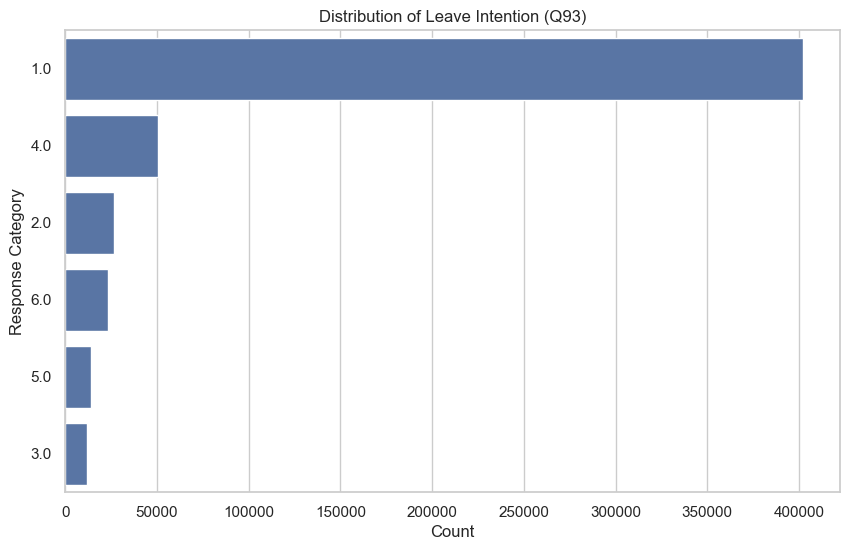

In [14]:
# Analyze Target Variable distribution (raw text/numbers might need coercion)
plt.figure(figsize=(10, 6))
sns.countplot(y='Q93', data=df, order=df['Q93'].value_counts().index)
plt.title('Distribution of Leave Intention (Q93)')
plt.xlabel('Count')
plt.ylabel('Response Category')
plt.show()

In [15]:
# Create Binary Target Variable
# 'X' or missing values are present in survey data, coerce them to numeric
df_clean = df.copy()
df_clean['Q93'] = pd.to_numeric(df_clean['Q93'], errors='coerce')

# Drop missing and 'retire' (2) as it's not typical turnover
df_clean = df_clean.dropna(subset=['Q93'])
df_clean = df_clean[df_clean['Q93'] != 2]

# 0 = No (1), 1 = Leave (3,4,5,6)
df_clean['Turnover_Intention'] = df_clean['Q93'].apply(lambda x: 1 if x in [3, 4, 5, 6] else 0)

print("Turnover Intention Class Distribution:")
print(df_clean['Turnover_Intention'].value_counts(normalize=True))

Turnover Intention Class Distribution:
Turnover_Intention
0    0.801565
1    0.198435
Name: proportion, dtype: float64


/var/folders/kc/wzqlm10x69xgkrpv4q3bp89w0000gn/T/ipykernel_3525/1055800270.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Turnover_Intention', data=df_clean, palette=['#2ECC71', '#E74C3C'])


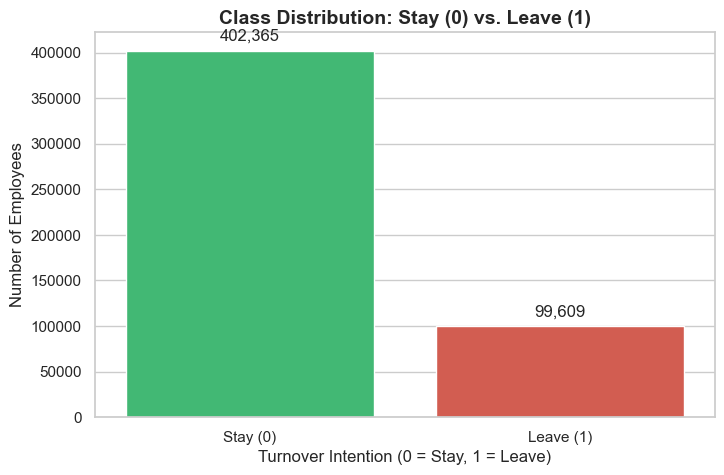

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set figure size
plt.figure(figsize=(8, 5))

# Plot Bar Chart
ax = sns.countplot(x='Turnover_Intention', data=df_clean, palette=['#2ECC71', '#E74C3C'])

# Format chart
plt.title('Class Distribution: Stay (0) vs. Leave (1)', fontsize=14, fontweight='bold')
plt.xlabel('Turnover Intention (0 = Stay, 1 = Leave)', fontsize=12)
plt.ylabel('Number of Employees', fontsize=12)
plt.xticks([0, 1], ['Stay (0)', 'Leave (1)'])

# Add value annotations on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=12, xytext=(0, 5), 
                textcoords='offset points')

plt.show()

## 2. Defined Feature Categories and Core Dimensions
We group the FEVS survey items into the 9 independent feature categories and visualize their correlation matrix against Turnover Intention.

In [17]:
# Define Feature Groups (Based on Table 2.1 in Thesis)
feature_groups = {
    'Personal_Work_Experience': [f'Q{i}' for i in range(1, 15)] + [f'Q{i}' for i in range(16, 19)],
    'Performance_Management': [f'Q15_{i}' for i in range(1, 7)],
    'Work_Unit_Dynamics': [f'Q{i}' for i in range(19, 30)],
    'Organizational_Culture': [f'Q{i}' for i in range(30, 43)],
    'Direct_Supervision': [f'Q{i}' for i in range(43, 53)],
    'Executive_Leadership': [f'Q{i}' for i in range(53, 63)],
    'Satisfaction_and_Rewards': [f'Q{i}' for i in range(63, 90)],
    'Workplace_Flexibilities': [f'Q{i}' for i in range(90, 93)],
    'Health_and_Safety_Support': [f'Q{i}' for i in range(94, 100)]
}

# Display feature groups with their Q-item ranges for readability
print("Defined Feature Categories with Q-item mapping:")
print(" - Personal_Work_Experience (Q1-Q14, Q16-Q18)")
print(" - Performance_Management (Q15_1-Q15_6)")
print(" - Work_Unit_Dynamics (Q19-Q29)")
print(" - Organizational_Culture (Q30-Q42)")
print(" - Direct_Supervision (Q43-Q52)")
print(" - Executive_Leadership (Q53-Q62)")
print(" - Satisfaction_and_Rewards (Q63-Q89)")
print(" - Workplace_Flexibilities (Q90-Q92)")
print(" - Health_and_Safety_Support (Q94-Q99)")


Defined Feature Categories with Q-item mapping:
 - Personal_Work_Experience (Q1-Q14, Q16-Q18)
 - Performance_Management (Q15_1-Q15_6)
 - Work_Unit_Dynamics (Q19-Q29)
 - Organizational_Culture (Q30-Q42)
 - Direct_Supervision (Q43-Q52)
 - Executive_Leadership (Q53-Q62)
 - Satisfaction_and_Rewards (Q63-Q89)
 - Workplace_Flexibilities (Q90-Q92)
 - Health_and_Safety_Support (Q94-Q99)


In [18]:
# Compute aggregated scores (Vectorized version)
# First, coerce all Q columns in df_clean to numeric
for col in df_clean.columns:
    if col.startswith('Q'):
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

new_indices = {}
for group_name, cols in feature_groups.items():
    available_cols = [c for c in cols if c in df_clean.columns]
    if available_cols:
        new_indices[f'Index_{group_name}'] = df_clean[available_cols].replace(-1, np.nan).mean(axis=1).fillna(-1)
    else:
        print(f"Warning: Columns for {group_name} not found in dataset.")

df_clean = pd.concat([df_clean, pd.DataFrame(new_indices)], axis=1)
print("Feature engineering complete. New engineered columns:")
print([col for col in df_clean.columns if col.startswith('Index_')])


Feature engineering complete. New engineered columns:
['Index_Personal_Work_Experience', 'Index_Performance_Management', 'Index_Work_Unit_Dynamics', 'Index_Organizational_Culture', 'Index_Direct_Supervision', 'Index_Executive_Leadership', 'Index_Satisfaction_and_Rewards', 'Index_Workplace_Flexibilities', 'Index_Health_and_Safety_Support']


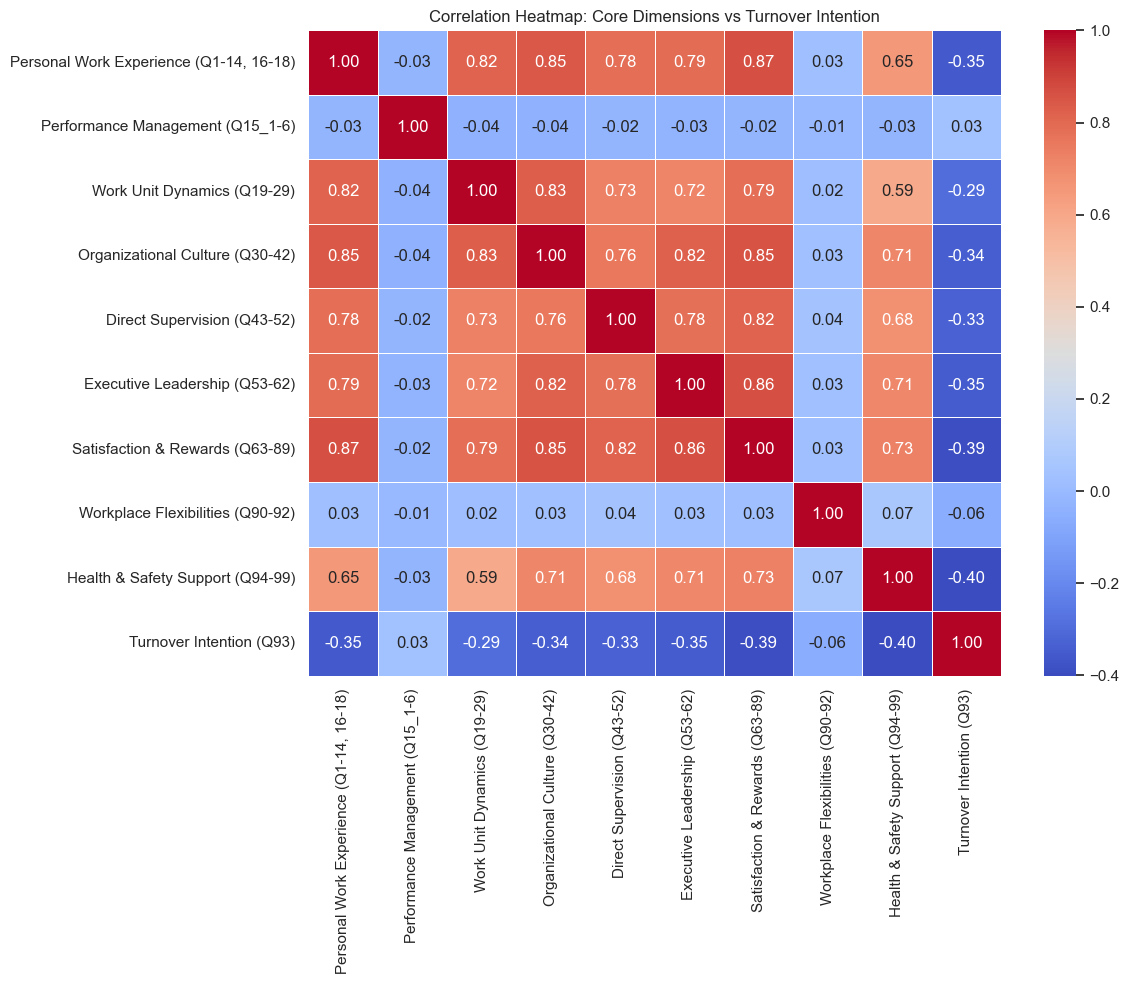

In [19]:
# Plot Correlation Heatmap: Core Dimensions vs Turnover Intention
index_cols = [col for col in df_clean.columns if col.startswith('Index_')]
plot_cols = index_cols + ['Turnover_Intention']

rename_mapping_core = {
    'Index_Personal_Work_Experience': 'Personal Work Experience (Q1-14, 16-18)',
    'Index_Performance_Management': 'Performance Management (Q15_1-6)',
    'Index_Work_Unit_Dynamics': 'Work Unit Dynamics (Q19-29)',
    'Index_Organizational_Culture': 'Organizational Culture (Q30-42)',
    'Index_Direct_Supervision': 'Direct Supervision (Q43-52)',
    'Index_Executive_Leadership': 'Executive Leadership (Q53-62)',
    'Index_Satisfaction_and_Rewards': 'Satisfaction & Rewards (Q63-89)',
    'Index_Workplace_Flexibilities': 'Workplace Flexibilities (Q90-92)',
    'Index_Health_and_Safety_Support': 'Health & Safety Support (Q94-99)',
    'Turnover_Intention': 'Turnover Intention (Q93)'
}

plot_df_core = df_clean[plot_cols].rename(columns=rename_mapping_core)

plt.figure(figsize=(12, 10))
corr_matrix_core = plot_df_core.corr()

sns.heatmap(corr_matrix_core, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap: Core Dimensions vs Turnover Intention')
plt.tight_layout()
plt.show()


### Correlation Heatmap of Top 10 Features
To understand the relationships between the data dimensions, we select the top 10 numerical features that are most highly correlated with `Turnover_Intention` and visualize their correlation matrix using a Heatmap.

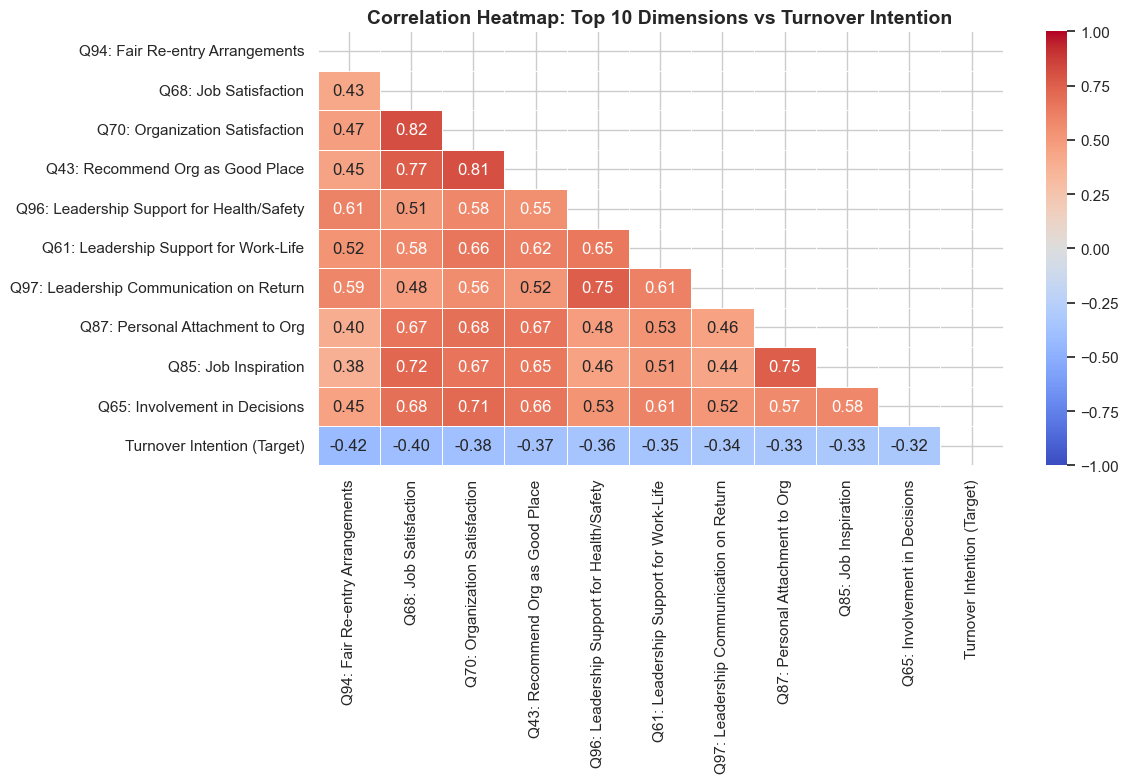

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Select only numeric columns for correlation (excluding target-derived Q93 and metadata)
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
numeric_cols = [c for c in numeric_cols if c not in ['Turnover_Intention', 'Q93', 'POSTWT', 'RANDOM_ID'] and not c.startswith('Index_')]

# Calculate correlation with Turnover_Intention
correlations = df_clean[numeric_cols + ['Turnover_Intention']].corr()['Turnover_Intention'].drop('Turnover_Intention').abs()

# Get the top 10 features with highest correlation
top_10_features = correlations.nlargest(10).index.tolist()

# Include Turnover_Intention in the heatmap
features_to_plot = top_10_features + ['Turnover_Intention']

# Define readable names for the Top 10 features for visualization
rename_mapping = {
    'Q94': 'Q94: Fair Re-entry Arrangements',
    'Q68': 'Q68: Job Satisfaction',
    'Q70': 'Q70: Organization Satisfaction',
    'Q43': 'Q43: Recommend Org as Good Place',
    'Q96': 'Q96: Leadership Support for Health/Safety',
    'Q61': 'Q61: Leadership Support for Work-Life',
    'Q97': 'Q97: Leadership Communication on Return',
    'Q87': 'Q87: Personal Attachment to Org',
    'Q85': 'Q85: Job Inspiration',
    'Q65': 'Q65: Involvement in Decisions',
    'Turnover_Intention': 'Turnover Intention (Target)'
}

# Create a temporary dataframe with renamed columns for the plot
plot_df = df_clean[features_to_plot].rename(columns=rename_mapping)

# Calculate the correlation matrix for these features
corr_matrix = plot_df.corr()

# Plot Heatmap
plt.figure(figsize=(12, 8))
# Using a mask to show only the lower triangle (optional, but makes it cleaner)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", 
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap: Top 10 Dimensions vs Turnover Intention', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()